In [8]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# EDA

In [ ]:
import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # 진행 상태 표시를 위한 라이브러리
import re
import numpy as np

C:\Users\Owner\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Owner\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


# 1. JPG 이미지 데이터 EDA

## 1-1. 파일 관련 분석

In [ ]:
# 이미지 데이터 경로
train_image_dir = "C:/Users/Owner/Desktop/DCC_DATA/training_image"
valid_image_dir = "C:/Users/Owner/Desktop/DCC_DATA/validation_image"

In [ ]:
# 이미지 파일 개수 확인
train_images = [f for f in os.listdir(train_image_dir) if f.endswith(".jpg")]
valid_images = [f for f in os.listdir(valid_image_dir) if f.endswith(".jpg")]

print(f"Number of training images: {len(train_images)}")
print(f"Number of validation images: {len(valid_images)}")

Number of training images: 4070
Number of validation images: 951


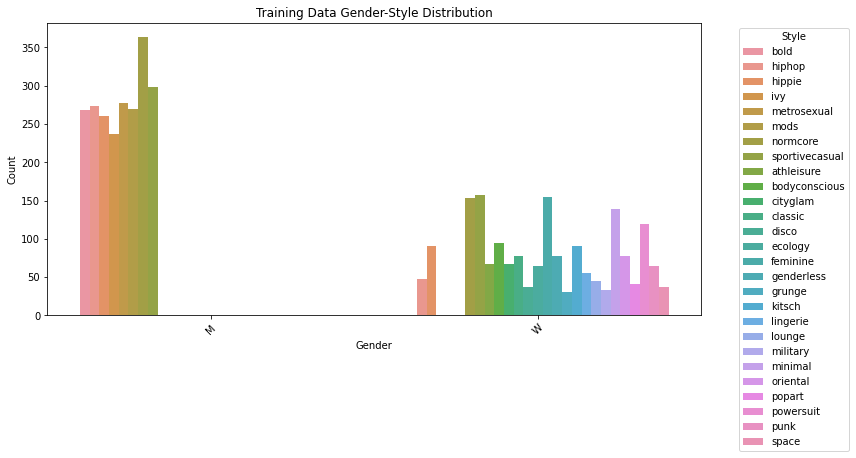

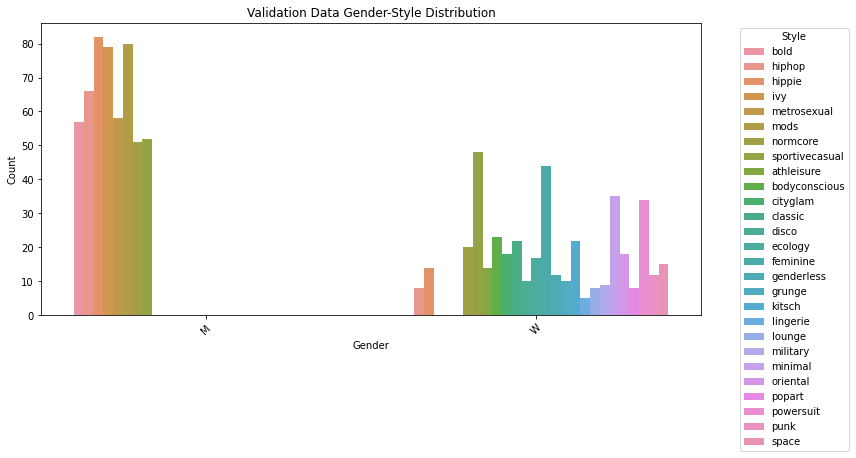

In [ ]:
# 성별 및 스타일별로 파일명에서 정보 추출
filename_pattern = r'^(W|T)_(\d+)_(\w+)_(\w+)_(\w+)\.jpg$'

def extract_image_info(image_list):
    extracted_info = []
    for filename in image_list:
        match = re.match(filename_pattern, filename)
        if match:
            gender, image_id, era, style, label_gender = match.groups()
            extracted_info.append((gender, era, style, label_gender))
    return pd.DataFrame(extracted_info, columns=["Set", "Era", "Style", "Gender"])

train_info = extract_image_info(train_images)
valid_info = extract_image_info(valid_images)

# 성별_스타일별 분포 확인
train_counts = train_info.groupby(["Gender", "Style"]).size().reset_index(name="Count")
valid_counts = valid_info.groupby(["Gender", "Style"]).size().reset_index(name="Count")

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=train_counts, x="Gender", y="Count", hue="Style")
plt.title("Training Data Gender-Style Distribution")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Style")  # 범례를 그래프 오른쪽으로 이동
plt.tight_layout()  # 레이아웃 조정
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=valid_counts, x="Gender", y="Count", hue="Style")
plt.title("Validation Data Gender-Style Distribution")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Style")  # 범례를 그래프 오른쪽으로 이동
plt.tight_layout()  # 레이아웃 조정
plt.show()


## 1-2. 이미지 크기 분석

In [ ]:
# 이미지 크기 확인
def get_image_sizes(image_dir, image_list):
    image_sizes = []
    for filename in image_list:
        img_path = os.path.join(image_dir, filename)
        with Image.open(img_path) as img:
            image_sizes.append(img.size)
    return pd.DataFrame(image_sizes, columns=["Width", "Height"])

train_sizes = get_image_sizes(train_image_dir, train_images)
valid_sizes = get_image_sizes(valid_image_dir, valid_images)

In [ ]:
# 크기 분포 확인
print("\nTraining Image Size Distribution:")
print(train_sizes.describe())

print("\nValidation Image Size Distribution:")
print(valid_sizes.describe())


Training Image Size Distribution:
        Width  Height
count  4070.0  4070.0
mean   3000.0  4000.0
std       0.0     0.0
min    3000.0  4000.0
25%    3000.0  4000.0
50%    3000.0  4000.0
75%    3000.0  4000.0
max    3000.0  4000.0

Validation Image Size Distribution:
        Width  Height
count   951.0   951.0
mean   3000.0  4000.0
std       0.0     0.0
min    3000.0  4000.0
25%    3000.0  4000.0
50%    3000.0  4000.0
75%    3000.0  4000.0
max    3000.0  4000.0


## 1-3. 색상, 밝기 분석

In [ ]:
# 성별 및 스타일별로 파일 정보 그룹화
def calculate_mean_colors_by_group(image_dir, image_list, metadata):
    group_mean_colors = []
    for _, group in metadata.groupby(['Gender', 'Style']):
        group_colors = []
        for img_name in group['ImageName']:
            img_path = os.path.join(image_dir, img_name)
            try:
                with Image.open(img_path).convert('RGB') as img:
                    img_array = np.array(img)
                    mean_color = img_array.mean(axis=(0, 1))  # 이미지의 평균 색상
                    group_colors.append(mean_color)
            except Exception as e:
                print(f"Error processing image {img_name}: {e}")

        # 그룹별 평균 색상 계산
        if group_colors:
            avg_color = np.mean(group_colors, axis=0)
            group_mean_colors.append({
                'Gender': group['Gender'].iloc[0],
                'Style': group['Style'].iloc[0],
                'Mean_Red': avg_color[0],
                'Mean_Green': avg_color[1],
                'Mean_Blue': avg_color[2]
            })

    return pd.DataFrame(group_mean_colors)

In [ ]:
# Training 데이터에 대해 수행
train_info['ImageName'] = train_images  # 이미지 파일명 연결
train_group_colors = calculate_mean_colors_by_group(train_image_dir, train_images, train_info)

# Validation 데이터에 대해 수행
valid_info['ImageName'] = valid_images  # 이미지 파일명 연결
valid_group_colors = calculate_mean_colors_by_group(valid_image_dir, valid_images, valid_info)

In [ ]:
# 결과 확인
print("Training Group Colors:")
print(train_group_colors)

print("\nValidation Group Colors:")
print(valid_group_colors)

Training Group Colors:
   Gender           Style    Mean_Red  Mean_Green   Mean_Blue
0       M            bold  135.040480  125.912507  122.865941
1       M          hiphop  133.849393  128.165295  124.541255
2       M          hippie  137.461933  127.758905  122.084310
3       M             ivy  133.157506  125.880421  121.868232
4       M     metrosexual  139.360822  132.512807  128.967994
5       M            mods  140.268037  135.799492  132.604426
6       M        normcore  142.520751  137.803644  134.360190
7       M  sportivecasual  142.082512  137.087937  133.075545
8       W      athleisure  150.095952  145.183010  143.188821
9       W   bodyconscious  146.054740  136.094069  128.795069
10      W        cityglam  131.911143  125.836318  120.069253
11      W         classic  142.954581  133.550030  129.082987
12      W           disco  138.560097  127.261753  119.467899
13      W         ecology  159.045672  153.094081  144.887153
14      W        feminine  152.128356  142.3893

<Figure size 7200x1008 with 0 Axes>

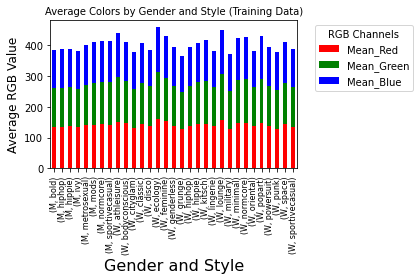

<Figure size 7200x1008 with 0 Axes>

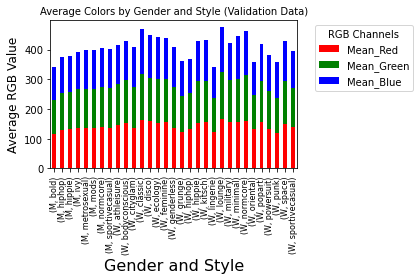

In [ ]:
plt.figure(figsize=(100, 14))
train_group_colors.set_index(['Gender', 'Style']).plot(kind='bar', stacked=True, color=['red', 'green', 'blue'])
plt.title("Average Colors by Gender and Style (Training Data)", fontsize=10)
plt.ylabel("Average RGB Value", fontsize=12)
plt.xlabel("Gender and Style", fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.legend(title="RGB Channels", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# Validation 데이터 평균 색상 시각화
plt.figure(figsize=(100, 14))
valid_group_colors.set_index(['Gender', 'Style']).plot(kind='bar', stacked=True, color=['red', 'green', 'blue'])
plt.title("Average Colors by Gender and Style (Validation Data)", fontsize=10)
plt.ylabel("Average RGB Value", fontsize=12)
plt.xlabel("Gender and Style", fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.legend(title="RGB Channels", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

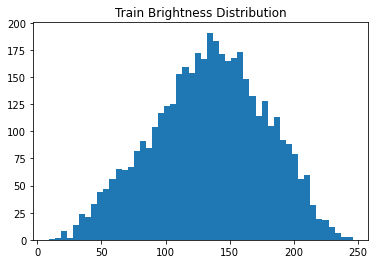

In [ ]:
tr_brightness = []
for img_file in os.listdir(train_image_dir):
    with Image.open(os.path.join(image_dir, img_file)) as img:
        img_array = np.array(img)
        brightness.append(np.mean(img_array))
plt.hist(brightness, bins=50)
plt.title("Train Brightness Distribution")
plt.show()

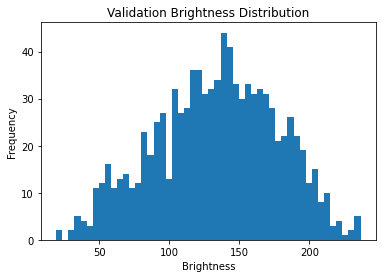

In [ ]:
val_brightness = []  # 밝기 값을 저장할 리스트
for img_file in os.listdir(valid_image_dir):  # valid_image_dir를 사용
    img_path = os.path.join(valid_image_dir, img_file)  # 올바른 경로 생성
    with Image.open(img_path) as img:  # 이미지 열기
        img_array = np.array(img)  # 이미지를 배열로 변환
        val_brightness.append(np.mean(img_array))  # 배열의 평균(밝기) 계산 후 추가

# 밝기 분포를 히스토그램으로 시각화
plt.hist(val_brightness, bins=50)
plt.title("Validation Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()


# 2. JSON 라벨링 데이터 EDA

## 2-1. 데이터 로드 및 구조 확인

In [ ]:
import json

train_json_dir = "C:/Users/Owner/Desktop/DCC_DATA/training_label"
valid_json_dir = "C:/Users/Owner/Desktop/DCC_DATA/validation_label"

In [ ]:
# JSON 파일 로드 및 구조 확인
def load_json_data(json_dir):
    data_list = []
    for file in os.listdir(json_dir):
        if file.endswith(".json"):
            with open(os.path.join(json_dir, file), "r") as f:
                data = json.load(f)
                data_list.append(data)
    return data_list

In [ ]:
train_json_data = load_json_data(train_json_dir)
valid_json_data = load_json_data(valid_json_dir)

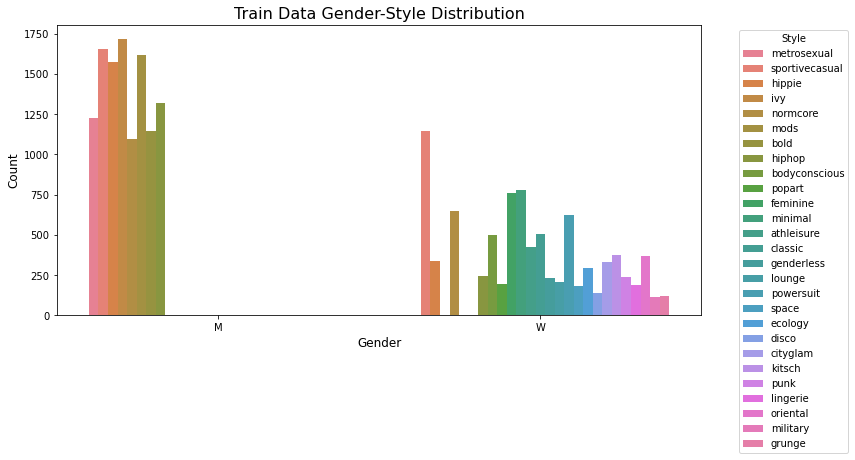

In [ ]:
# 데이터셋 1
data1 = {
    "성별": ["M"] * 8 + ["W"] * 23,
    "스타일": [
        "metrosexual", "sportivecasual", "hippie", "ivy", "normcore", "mods", "bold", "hiphop",
        "bodyconscious", "popart", "feminine", "minimal", "normcore", "athleisure", "classic",
        "genderless", "sportivecasual", "lounge", "powersuit", "hippie", "hiphop", "space",
        "ecology", "disco", "cityglam", "kitsch", "punk", "lingerie", "oriental", "military", "grunge"
    ],
    "이미지 수": [
        1226, 1657, 1571, 1719, 1096, 1615, 1144, 1321,
        500, 195, 762, 780, 646, 424, 504, 234, 1143, 207, 623, 339, 243,
        184, 295, 141, 329, 374, 237, 188, 369, 115, 122
    ]
}

# 데이터 프레임 생성
df1 = pd.DataFrame(data1)

# 그래프 생성
plt.figure(figsize=(12, 6))
sns.barplot(data=df1, x="성별", y="이미지 수", hue="스타일", dodge=True, palette="husl")

# 제목 및 축 설정
plt.title("Train Data Gender-Style Distribution", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Style", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


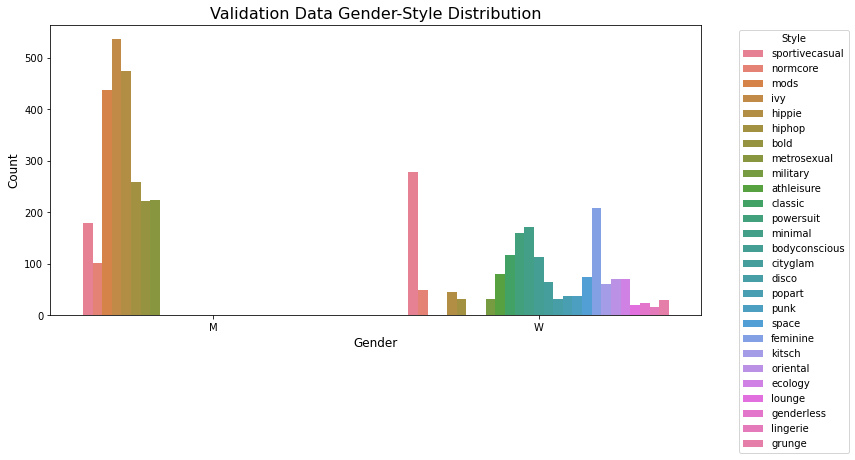

In [ ]:
# 데이터셋 2
data2 = {
    "성별": ["M"] * 8 + ["W"] * 23,
    "스타일": [
        "sportivecasual", "normcore", "mods", "ivy", "hippie", "hiphop", "bold", "metrosexual",
        "military", "athleisure", "normcore", "classic", "powersuit", "minimal", "bodyconscious",
        "cityglam", "disco", "popart", "hiphop", "punk", "space", "feminine", "kitsch",
        "sportivecasual", "hippie", "oriental", "ecology", "lounge", "genderless", "lingerie", "grunge"
    ],
    "이미지 수": [
        180, 102, 438, 537, 474, 259, 221, 224,
        32, 80, 50, 117, 160, 171, 114, 65, 31, 38, 32, 38, 75, 208, 61, 278,
        46, 71, 70, 20, 24, 17, 29
    ]
}

# 데이터 프레임 생성
df2 = pd.DataFrame(data2)

# 그래프 생성 - Dataset 2
plt.figure(figsize=(12, 6))
sns.barplot(data=df2, x="성별", y="이미지 수", hue="스타일", dodge=True, palette="husl")

# 제목 및 축 설정
plt.title("Validation Data Gender-Style Distribution", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Style", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
# 설문 정보 필드는 aihub 어노테이션 포맷 표 참고

## 2-2. 설문 데이터 정리 및 시각화

In [ ]:
# JSON 데이터 정리
def flatten_json_data(json_data):
    flattened_data = []
    for entry in json_data:
        flattened_entry = {
            "E_id": entry.get("E_id"),
            "imgName": entry.get("imgName"),
            **entry.get("item", {}),
            **entry.get("item", {}).get("survey", {}),
            **entry.get("user", {}),
        }
        flattened_data.append(flattened_entry)
    return pd.DataFrame(flattened_data)

train_label_df = flatten_json_data(train_json_data)
valid_label_df = flatten_json_data(valid_json_data)

# 'survey_Q5' 값 분포 확인 (선호/비선호)
print("\nTraining Survey Q5 Distribution:")
print(train_label_df["Q5"].value_counts())

print("\nValidation Survey Q5 Distribution:")
print(valid_label_df["Q5"].value_counts())



Training Survey Q5 Distribution:
Q5
1    127162
2     84184
Name: count, dtype: int64

Validation Survey Q5 Distribution:
Q5
1    21896
2    14487
Name: count, dtype: int64


In [ ]:
# 'style' 값 분포 확인
print("\nTraining Survey style Distribution:")
print(train_label_df["style"].value_counts())

print("\nValidation Survey style Distribution:")
print(valid_label_df["style"].value_counts())

# 'gender' 값 분포 확인
print("\nTraining Survey gender Distribution:")
print(train_label_df["gender"].value_counts())

print("\nValidation Survey gender Distribution:")
print(valid_label_df["gender"].value_counts())


Training Survey style Distribution:
style
sportivecasual    23095
normcore          22937
hippie            15079
powersuit         13058
hiphop            11529
feminine          11455
minimal           10980
bold               9957
ivy                9374
metrosexual        9002
mods               8948
classic            6558
kitsch             6346
cityglam           5889
punk               5852
oriental           5221
bodyconscious      4450
lounge             4210
ecology            3934
genderless         3503
disco              3491
popart             3298
space              3075
lingerie           2981
athleisure         2883
military           2213
grunge             2028
Name: count, dtype: int64

Validation Survey style Distribution:
style
sportivecasual    4151
normcore          3194
hippie            2970
powersuit         2334
ivy               2129
feminine          2091
hiphop            1984
minimal           1799
mods              1770
bold              1609
metrosex

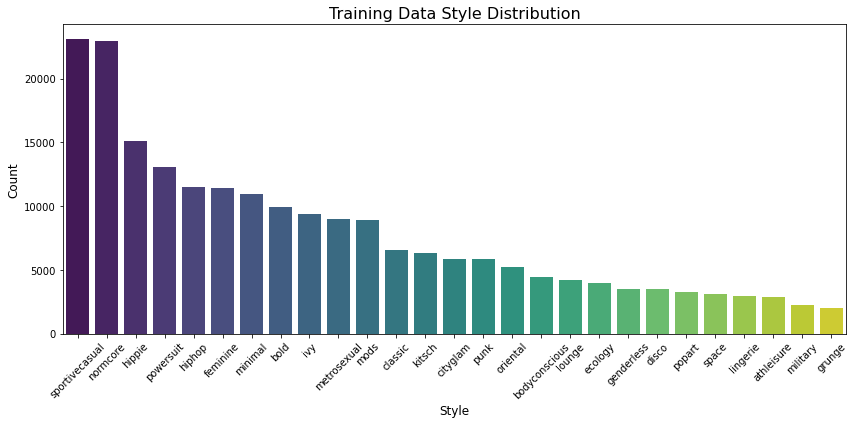

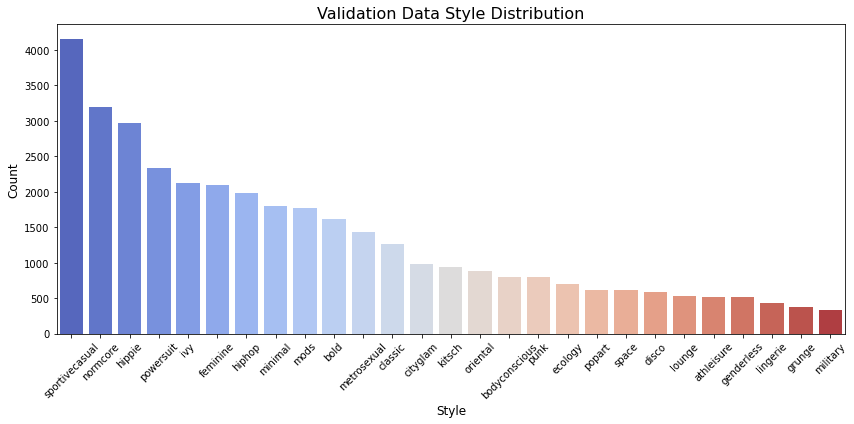

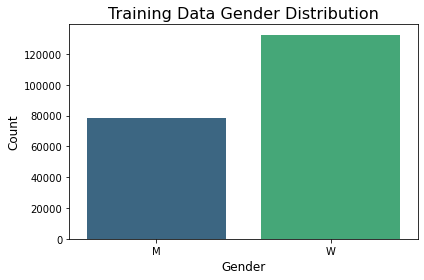

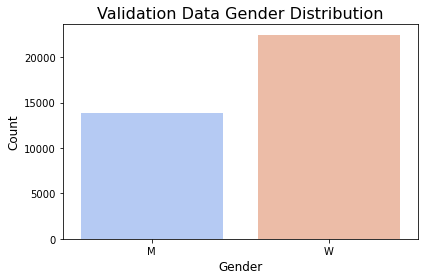

In [ ]:
# 스타일 분포 시각화 (Training 데이터)
plt.figure(figsize=(12, 6))
sns.countplot(data=train_label_df, x="style", order=train_label_df["style"].value_counts().index, palette="viridis")
plt.title("Training Data Style Distribution", fontsize=16)
plt.xlabel("Style", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()

# 스타일 분포 시각화 (Validation 데이터)
plt.figure(figsize=(12, 6))
sns.countplot(data=valid_label_df, x="style", order=valid_label_df["style"].value_counts().index, palette="coolwarm")
plt.title("Validation Data Style Distribution", fontsize=16)
plt.xlabel("Style", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()

# 성별 분포 시각화 (Training 데이터)
plt.figure(figsize=(6, 4))
sns.countplot(data=train_label_df, x="gender", palette="viridis")
plt.title("Training Data Gender Distribution", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# 성별 분포 시각화 (Validation 데이터)
plt.figure(figsize=(6, 4))
sns.countplot(data=valid_label_df, x="gender", palette="coolwarm")
plt.title("Validation Data Gender Distribution", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# 설문 항목 추출
survey_columns = [col for col in train_label_df.columns if col.startswith('Q')]

# Training 데이터에서 설문 항목 값 분포 계산 및 출력
print("Training Survey Counts:")
for survey_col in survey_columns:
    print(f"\n{survey_col}:")
    print(train_label_df[survey_col].value_counts().sort_index())  # 값 분포 계산 및 출력

# Validation 데이터에서 설문 항목 값 분포 계산 및 출력
print("\nValidation Survey Counts:")
for survey_col in survey_columns:
    print(f"\n{survey_col}:")
    print(valid_label_df[survey_col].value_counts().sort_index())  # 값 분포 계산 및 출력


Training Survey Counts:

Q1:
Q1
1    61477
2    66000
3    66440
4    17429
Name: count, dtype: int64

Q2:
Q2
1    115777
2     53027
3     42542
Name: count, dtype: int64

Q3:
Q3
1    19608
2    27297
3    18409
4    47073
5    57216
6    10947
7    17817
8    12979
Name: count, dtype: int64

Q411:
Q411
1     61476
2    119278
3     30592
Name: count, dtype: int64

Q412:
Q412
1     91439
2    119907
Name: count, dtype: int64

Q413:
Q413
1     94273
2    117073
Name: count, dtype: int64

Q414:
Q414
1     75531
2    135815
Name: count, dtype: int64

Q4201:
Q4201
0    173921
1     37425
Name: count, dtype: int64

Q4202:
Q4202
0    149398
2     61948
Name: count, dtype: int64

Q4203:
Q4203
0    146641
3     64705
Name: count, dtype: int64

Q4204:
Q4204
0    153221
4     58125
Name: count, dtype: int64

Q4205:
Q4205
0    158028
5     53318
Name: count, dtype: int64

Q4206:
Q4206
0    162669
6     48677
Name: count, dtype: int64

Q4207:
Q4207
0    142256
7     69090
Name: count, dtype: int6

Training Survey Counts:


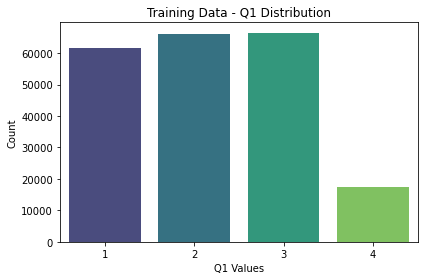

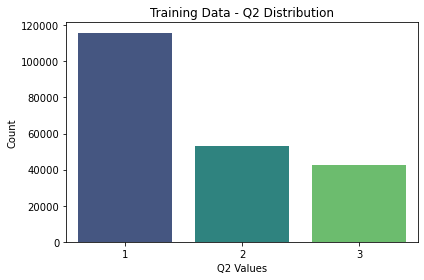

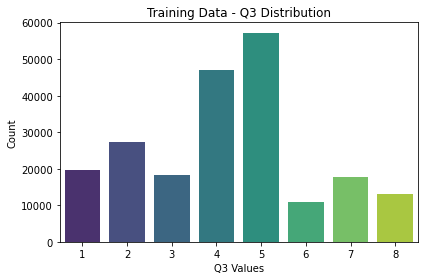

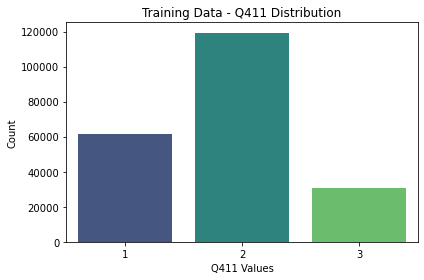

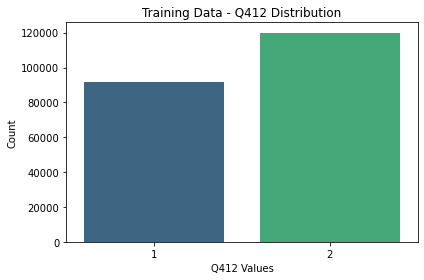

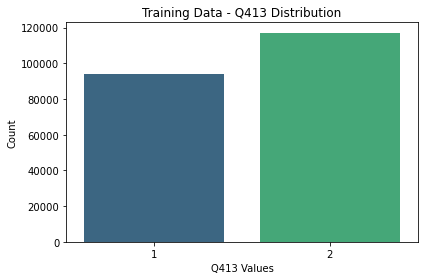

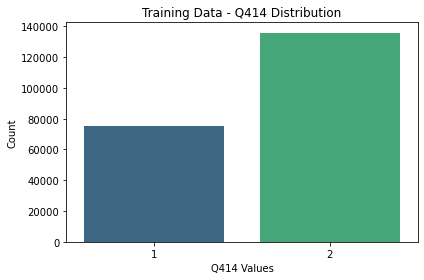

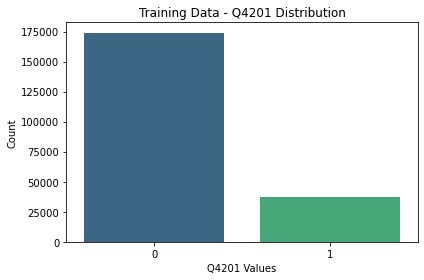

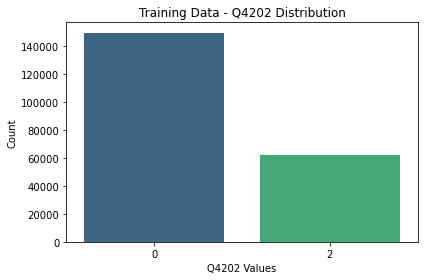

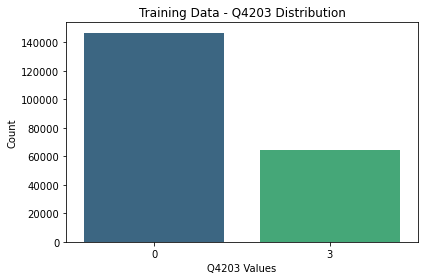

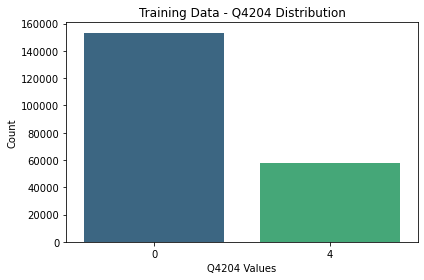

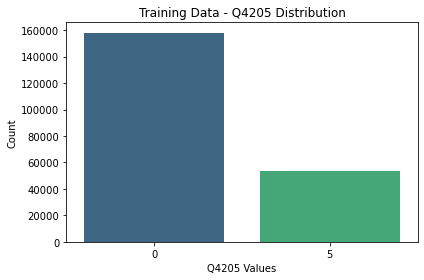

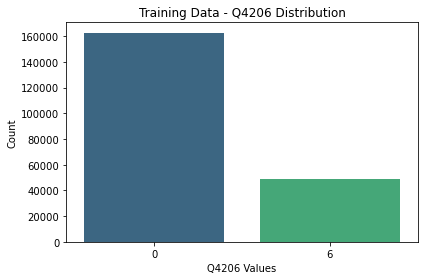

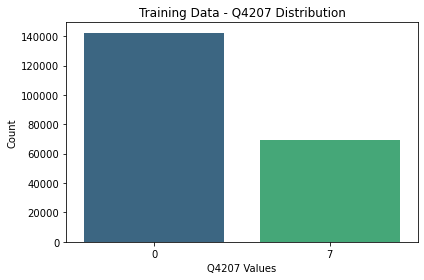

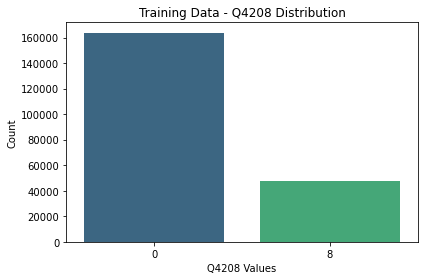

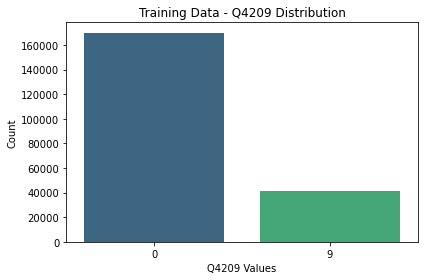

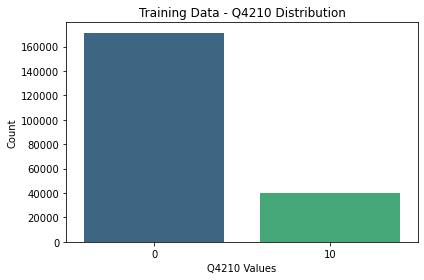

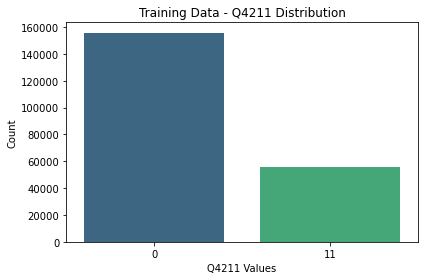

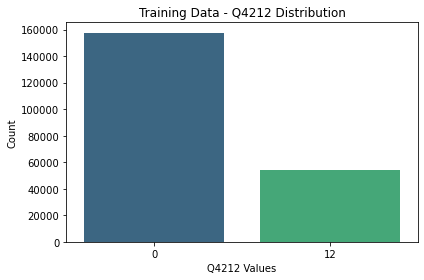

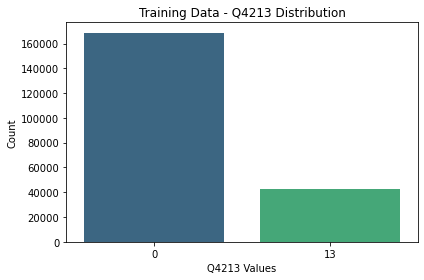

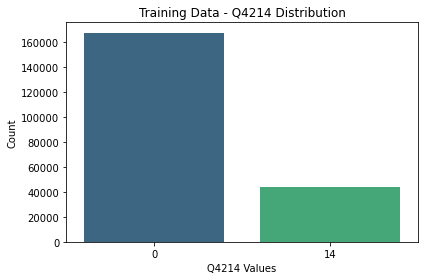

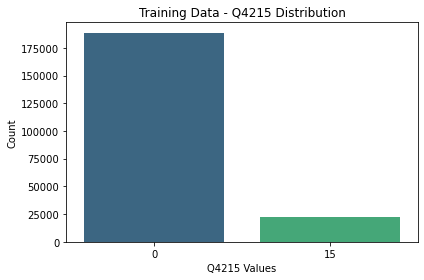

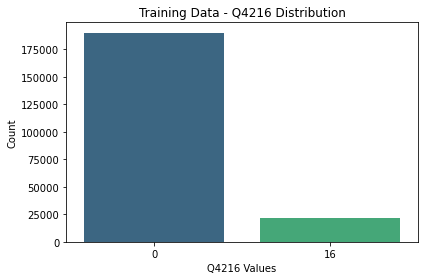

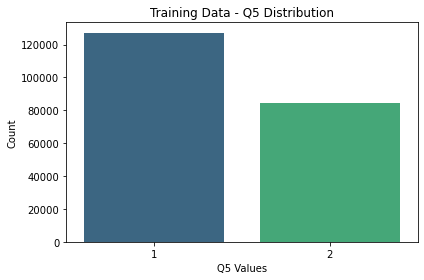


Validation Survey Counts:


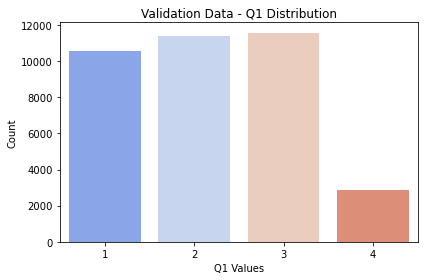

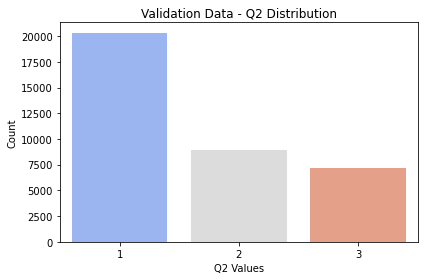

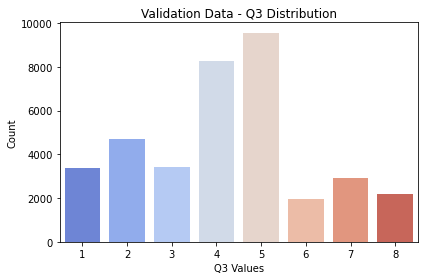

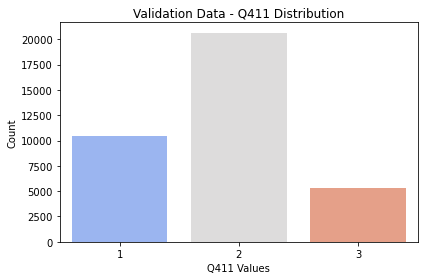

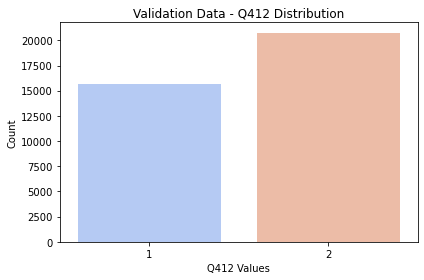

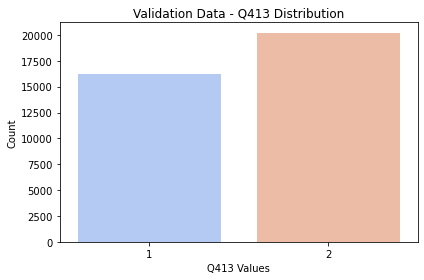

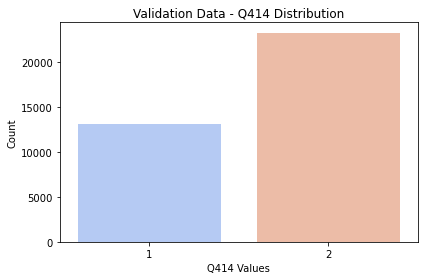

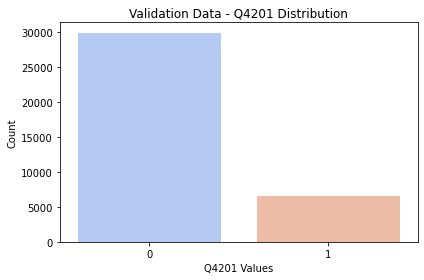

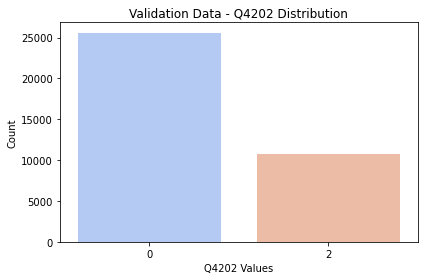

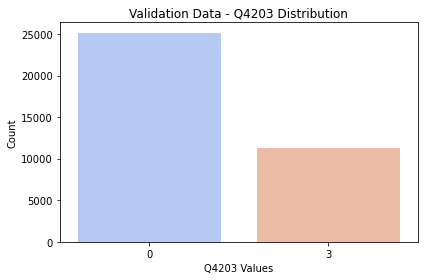

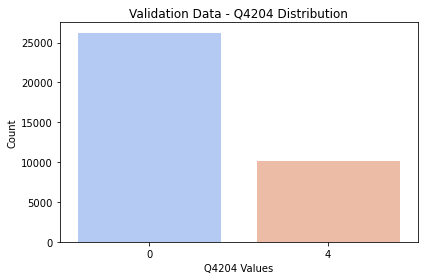

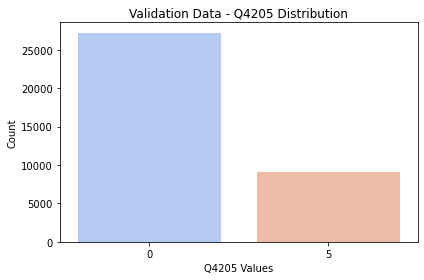

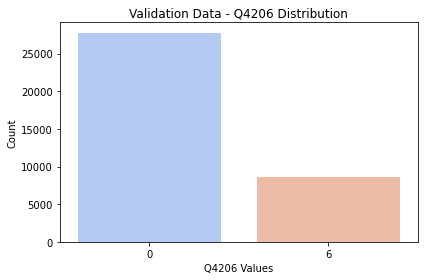

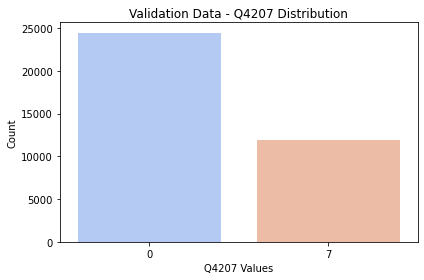

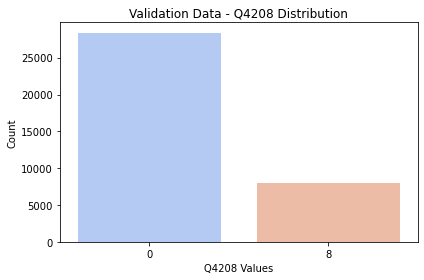

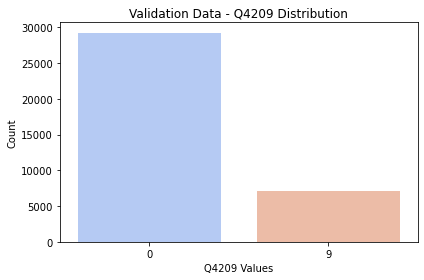

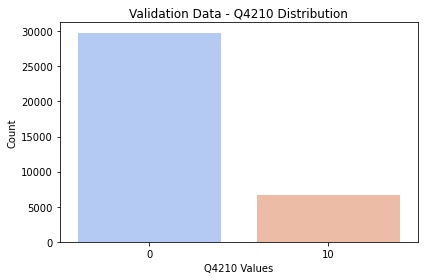

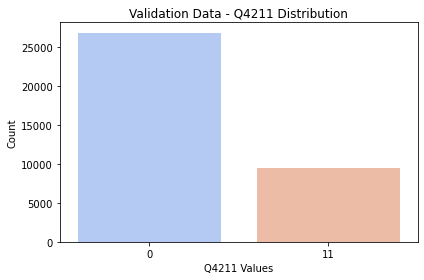

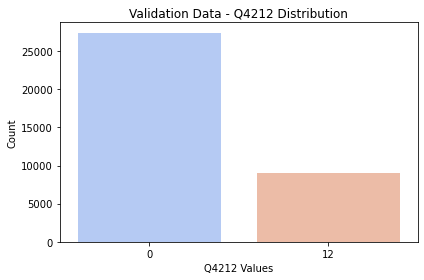

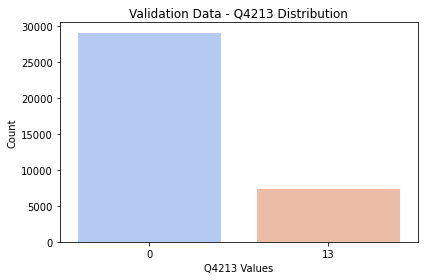

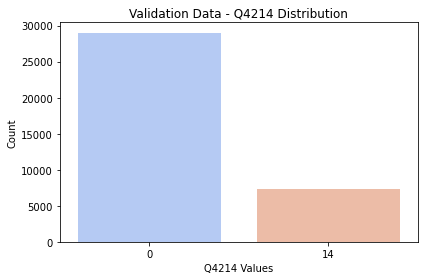

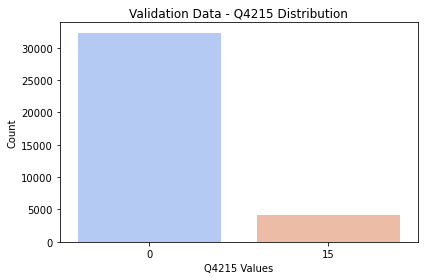

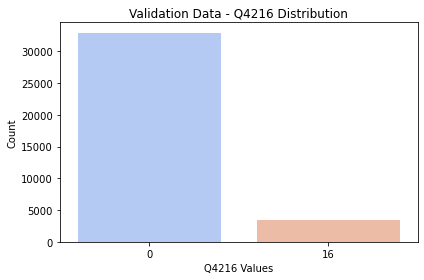

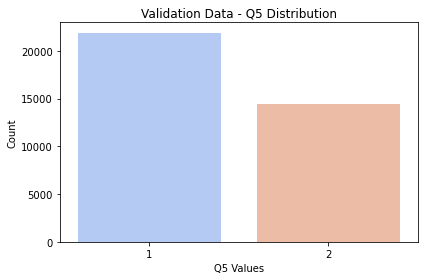

In [ ]:
# Training 데이터에서 설문 항목 값 분포 시각화
print("Training Survey Counts:")
for survey_col in survey_columns:
    plt.figure(figsize=(6, 4))
    count_data = train_label_df[survey_col].value_counts().sort_index()  # 값 분포 계산
    sns.barplot(x=count_data.index, y=count_data.values, palette='viridis')
    plt.title(f"Training Data - {survey_col} Distribution")
    plt.xlabel(f"{survey_col} Values")
    plt.ylabel("Count")
    plt.xticks()
    plt.tight_layout()
    plt.show()

# Validation 데이터에서 설문 항목 값 분포 시각화
print("\nValidation Survey Counts:")
for survey_col in survey_columns:
    plt.figure(figsize=(6, 4))
    count_data = valid_label_df[survey_col].value_counts().sort_index()  # 값 분포 계산
    sns.barplot(x=count_data.index, y=count_data.values, palette='coolwarm')
    plt.title(f"Validation Data - {survey_col} Distribution")
    plt.xlabel(f"{survey_col} Values")
    plt.ylabel("Count")
    plt.xticks()
    plt.tight_layout()
    plt.show()

# MISSION 1-1

In [ ]:
# 라이브러리 임포트
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import pandas as pd

In [ ]:
# 이미지 디렉토리 설정
training_image_dir = '/content/drive/MyDrive/data/training_image/'
validation_image_dir = '/content/drive/MyDrive/data/validation_image/'

In [ ]:
# 파일 이름에서 성별과 스타일을 추출하는 함수
def extract_info_from_filename(filename):
    # 파일 이름에서 확장자를 제거
    file_name_without_ext = os.path.splitext(filename)[0]

    # 파일 이름을 '_'로 구분
    parts = file_name_without_ext.split('_')

    # 성별은 마지막 부분에 위치
    gender = parts[-1]

    # 스타일은 성별 바로 앞 부분
    style = parts[-2]

    return gender, style

In [ ]:
# 주어진 디렉토리의 파일 목록을 처리하여 성별과 스타일별 집계를 생성하는 함수
def process_image_directory(image_dir):
    file_list = os.listdir(image_dir)
    data = []

    for file_name in file_list:
        if file_name.endswith('.jpg'):
            gender, style = extract_info_from_filename(file_name)
            # 성별 값 변환
            gender_name = '여성' if gender == 'W' else '남성'
            data.append({'성별': gender_name, '스타일': style, '이미지 수': 1})

    df = pd.DataFrame(data)
    # 성별과 스타일별로 그룹화하여 이미지 수 계산
    gender_style_count = df.groupby(['성별', '스타일']).size().reset_index(name='이미지 수')

    return gender_style_count

In [ ]:
# Training 이미지 데이터 처리
training_table = process_image_directory(training_image_dir)
training_table

,성별,스타일,이미지 수
0,남성,bold,268
1,남성,hiphop,274
2,남성,hippie,260
3,남성,ivy,237
4,남성,metrosexual,278
5,남성,mods,269
6,남성,normcore,364
7,남성,sportivecasual,298
8,여성,athleisure,67
9,여성,bodyconscious,95


In [ ]:
# Validation 이미지 데이터 처리
validation_table = process_image_directory(validation_image_dir)
validation_table

,성별,스타일,이미지 수
0,남성,bold,57
1,남성,hiphop,66
2,남성,hippie,82
3,남성,ivy,79
4,남성,metrosexual,58
5,남성,mods,80
6,남성,normcore,51
7,남성,sportivecasual,52
8,여성,athleisure,14
9,여성,bodyconscious,23


# 클래스 별 폴더 만들기 : dataclass

In [ ]:
import os
import shutil

# 기본 디렉토리 설정
train_image_dir = '/content/drive/MyDrive/data/training_image'  # 원본 이미지 디렉토리 경로
train_target_dir = '/content/drive/MyDrive/data/data_class/training'  # 클래스 폴더 디렉토리 경로

# 성별_스타일 클래스 폴더 생성 및 이미지 복사
for index, row in training_table.iterrows():
    class_name = f"{row['Gender']}_{row['Style']}"
    class_folder = os.path.join(train_target_dir, class_name)

    # 클래스 폴더가 없으면 생성
    os.makedirs(class_folder, exist_ok=True)

    # 해당 클래스에 맞는 이미지 복사
    for filename in os.listdir(train_image_dir):
        if filename.endswith(".jpg"):
            parts = filename[:-4].split('_')
            if len(parts) >= 5:
                gender = parts[4]
                style = parts[3]

                # 성별과 스타일이 일치하면 파일 복사
                if gender == row['Gender'] and style == row['Style']:
                    src_path = os.path.join(train_image_dir, filename)
                    dst_path = os.path.join(class_folder, filename)
                    shutil.copyfile(src_path, dst_path)
                    print(f"Copied {filename} to {class_folder}")

In [ ]:
import shutil

# 기본 디렉토리 설정
validation_image_dir = '/content/drive/MyDrive/data/validation_image'  # 원본 이미지 디렉토리 경로
validation_target_dir = '/content/drive/MyDrive/data/data_class/validation'  # 클래스 폴더 디렉토리 경로

# 성별_스타일 클래스 폴더 생성 및 이미지 복사
for index, row in validation_table.iterrows():
    class_name = f"{row['Gender']}_{row['Style']}"
    class_folder = os.path.join(validation_target_dir, class_name)

    # 클래스 폴더가 없으면 생성
    os.makedirs(class_folder, exist_ok=True)

    # 해당 클래스에 맞는 이미지 복사
    for filename in os.listdir(validation_image_dir):
        if filename.endswith(".jpg"):  # 확장자 확인 (필요에 따라 조정)
            parts = filename[:-4].split('_')
            if len(parts) >= 5:
                gender = parts[4]
                style = parts[3]

                # 성별과 스타일이 일치하면 파일 복사
                if gender == row['Gender'] and style == row['Style']:
                    src_path = os.path.join(validation_image_dir, filename)
                    dst_path = os.path.join(class_folder, filename)
                    shutil.copyfile(src_path, dst_path)
                    print(f"Copied {filename} to {class_folder}")

# yolo를 활용한 detect crop 폴더 만들기

In [ ]:
#  YOLOv5 모델을 설치하고 필요한 종속성을 설정
!git clone https://github.com/ultralytics/yolov5  # clone
%cd yolov5
%pip install -qr requirements.txt comet_ml  # install

In [ ]:
import torch
import utils
display = utils.notebook_init()  #  모델 훈련을 위한 초기 환경을 설정

### train yolo detect crop

In [ ]:
import os
import glob
import cv2


# 클래스별 이미지 디렉토리 설정
train_data_class = '/content/drive/MyDrive/data/data_class/training'
# 검출된 객체 영역을 저장할 디렉토리 설정
extracted_objects_dir = '/content/drive/MyDrive/data/crop_objects_image'
os.makedirs(extracted_objects_dir, exist_ok=True)

# 각 클래스 폴더를 순회
for class_folder in os.listdir(train_data_class):
    class_path = os.path.join(train_data_class, class_folder)

    if os.path.isdir(class_path):
        image_paths = glob.glob(os.path.join(class_path, '*.jpg'))

        for image_path in image_paths:
            print(f"Processing image: {image_path}")
            # YOLOv5 객체 검출 수행
            !python detect.py --weights yolov5s.pt --img 640 --conf 0.25 --source {image_path} --save-txt --save-crop --project {extracted_objects_dir} --name {class_folder} --exist-ok

print("Completed extracting the largest objects.")

In [ ]:
# 클래스 파일 목록을 가져오는 함수
def get_class_folders(directory):
    try:
        # 디렉토리 안의 폴더들을 탐색하여 리스트에 저장
        class_folders = [f.name for f in os.scandir(directory) if f.is_dir()]
        return class_folders
    except FileNotFoundError:
        print("Directory not found.")
        return []

# 클래스 폴더 목록을 리스트에 저장
class_folders = get_class_folders(extracted_objects_dir)

# 리스트 출력
class_folders

In [ ]:
from PIL import Image
import shutil

In [ ]:
# 경로 설정
base_dir = "/content/drive/MyDrive/data/crop_objects_image"
target_dir = "/content/drive/MyDrive/data/crop_objects_image_selected"  # 선택된 이미지를 저장할 경로

In [ ]:
# 클래스 폴더를 선회하고, 이미지 비교 후 복사하는 함수
def select_and_copy_largest_images(class_folders):
    for class_folder in class_folders:
        class_path = os.path.join(base_dir, class_folder, "crops/person")

        if not os.path.exists(class_path):
            print(f"{class_path} 경로가 존재하지 않습니다.")
            continue

        # 이미지 그룹화 (공통 부분으로 그룹화)
        image_groups = {}

        # 폴더 내의 이미지 파일 탐색
        for filename in os.listdir(class_path):
            if filename.endswith(".jpg"):
                # 공통 이미지 ID 추출 (이름의 끝 부분을 제외한 부분)
                image_id = '_'.join(filename.split('_')[:3])

                # 이미지 경로
                image_path = os.path.join(class_path, filename)

                # 이미지 크기 확인
                with Image.open(image_path) as img:
                    width, height = img.size
                    area = width * height

                # 동일 이미지 ID가 이미 있는 경우 크기 비교
                if image_id not in image_groups or image_groups[image_id][1] < area:
                    image_groups[image_id] = (filename, area)

        # 가장 큰 이미지를 새로운 경로로 복사
        for image_id, (largest_filename, _) in image_groups.items():
            src_image_path = os.path.join(class_path, largest_filename)
            dest_class_path = os.path.join(target_dir, class_folder)

            # 복사할 대상 폴더가 없다면 생성
            os.makedirs(dest_class_path, exist_ok=True)

            # 이미지 복사
            dest_image_path = os.path.join(dest_class_path, largest_filename)
            shutil.copy2(src_image_path, dest_image_path)
            print(f"Copied: {largest_filename} to {dest_image_path}")

In [ ]:
# 가장 큰 이미지를 선택하고 복사
select_and_copy_largest_images(class_folders)

### valid yolo detect crop

In [ ]:
# 클래스별 이미지 디렉토리 설정 (검증 데이터 경로)
valid_data_class = '/content/drive/MyDrive/data/data_class/validation'
# 검출된 객체 영역을 저장할 디렉토리 설정
extracted_objects_valid_dir = '/content/drive/MyDrive/data/crop_objects_valid_image'
os.makedirs(extracted_objects_valid_dir, exist_ok=True)

# 각 클래스 폴더를 순회
for class_folder in os.listdir(valid_data_class):
    class_path = os.path.join(valid_data_class, class_folder)

    if os.path.isdir(class_path):
        image_paths = glob.glob(os.path.join(class_path, '*.jpg'))

        for image_path in image_paths:
            print(f"Processing image: {image_path}")
            # YOLOv5 객체 검출 수행
            !python detect.py --weights yolov5s.pt --img 640 --conf 0.25 --source {image_path} --save-txt --save-crop --project {extracted_objects_valid_dir} --name {class_folder} --exist-ok

print("Completed processing images.")

In [ ]:
# 경로 설정
valid_base_dir = "/content/drive/MyDrive/data/crop_objects_valid_image"
valid_target_dir = "/content/drive/MyDrive/data/crop_objects_valid_image_selected"  # 선택된 이미지를 저장할 경로

In [ ]:
# 클래스 폴더 목록을 리스트에 저장
valid_class_folders = get_class_folders(valid_base_dir)

# 리스트 출력
valid_class_folders

In [ ]:
def select_and_copy_largest_images_valid(class_folders):
    for class_folder in class_folders:
        class_path = os.path.join(valid_base_dir, class_folder, "crops/person")

        if not os.path.exists(class_path):
            print(f"{class_path} 경로가 존재하지 않습니다.")
            continue

        # 이미지 그룹화 (공통 부분으로 그룹화)
        image_groups = {}

        # 폴더 내의 이미지 파일 탐색
        for filename in os.listdir(class_path):
            if filename.endswith(".jpg"):
                # 공통 이미지 ID 추출 (이름의 끝 부분을 제외한 부분)
                image_id = '_'.join(filename.split('_')[:3])

                # 이미지 경로
                image_path = os.path.join(class_path, filename)

                # 이미지 크기 확인
                with Image.open(image_path) as img:
                    width, height = img.size
                    area = width * height

                # 동일 이미지 ID가 이미 있는 경우 크기 비교
                if image_id not in image_groups or image_groups[image_id][1] < area:
                    image_groups[image_id] = (filename, area)

        # 가장 큰 이미지를 새로운 경로로 복사
        for image_id, (largest_filename, _) in image_groups.items():
            src_image_path = os.path.join(class_path, largest_filename)
            dest_class_path = os.path.join(valid_target_dir, class_folder)

            # 복사할 대상 폴더가 없다면 생성
            os.makedirs(dest_class_path, exist_ok=True)

            # 이미지 복사
            dest_image_path = os.path.join(dest_class_path, largest_filename)
            shutil.copy2(src_image_path, dest_image_path)
            print(f"Copied: {largest_filename} to {dest_image_path}")

In [ ]:
# 가장 큰 이미지를 선택하고 복사
select_and_copy_largest_images_valid(class_folders)

# MISSION 1-2

In [ ]:
# Google Drive를 마운트하여 Google Drive 파일에 접근
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 필요한 라이브러리 임포트
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

In [ ]:
# 디바이스 선택: GPU가 사용 가능하면 'cuda', 그렇지 않으면 'cpu'를 사용하여 모델 학습
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
# 데이터 파일 경로 설정 (이미지 폴더 지정)
crop_train = '/content/drive/MyDrive/data/crop_objects_image_selected'
crop_valid = '/content/drive/MyDrive/data/crop_objects_valid_image_selected'

In [ ]:
# 하이퍼파라미터 설정
batch_size = 32 # 배치 크기: 32로 설정한 이유는 메모리 효율성과 학습 안정성의 균형을 맞추기 위함입니다.일반적으로 32~64 사이가 많이 쓰입니다.
learning_rate = 0.001 # 0.001은 Adam 옵티마이저에서 많이 사용되는 기본 학습률로, 안정적인 수렴을 보이는 경우가 많아 초기 값으로 적합합니다.
epochs = 100 # 데이터가 충분하고 모델이 잘 학습되는 경우에 일반적으로 수십에서 수백 사이가 적합합니다.
patience = 10  # Early Stopping을 위한 patience: 연속적으로 검증 손실이 개선되지 않는 경우 학습을 중단하기 위한 기준입니다.
# 10회 연속으로 개선되지 않으면 중단하며, 이 수치는 모델이 최적화되지 않는 상황을 방지하는 데 유용합니다.

In [ ]:
# 데이터 증강 및 정규화 설정 (학습과 검증에 다른 변환을 적용)
# 학습 데이터 변환: 다양한 증강 기법을 사용하여 모델이 다양한 이미지 변형에 잘 적응할 수 있도록 함
transform_train = transforms.Compose([
    transforms.Resize((224, 224)), # 이미지를 ResNet 모델의 표준 입력 크기인 224x224로 변환
    transforms.RandomHorizontalFlip(), # 수평 반전은 이미지에 방향성이 없는 경우 좋은 데이터 증강 기법입니다.
    transforms.RandomRotation(15), # 15도 내외의 회전을 통해 모델이 회전 변형에 대해 학습할 수 있도록 합니다.
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 랜덤 크롭 및 리사이즈로 다양한 배경을 학습하게 함
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # 색조 변형을 통해 다양한 색상을 학습
    transforms.ToTensor(),# 데이터를 텐서 형식으로 변환하여 모델에 입력할 수 있도록 함
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # 일반적인 이미지넷 평균 및 표준편차로 정규화
])
# 검증 데이터 변환: 테스트 이미지와 같은 정규화만 적용하여 모델 성능 평가
transform_valid = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# 데이터셋 로드
train_dataset = datasets.ImageFolder(root=crop_train, transform=transform_train)
valid_dataset = datasets.ImageFolder(root=crop_valid, transform=transform_valid)

In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(dataset=valid_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# ResNet-18 모델 정의 (커스텀)
# ResNet18은 층이 쌓일수록 발생하는 '기울기 소실 문제'를 해결하기 위해 잔차 블록을 활용한 모델
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

In [ ]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 레이어 쌓기
        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        layers = [BasicBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
# 모델 초기화 및 디바이스로 이동
model = ResNet18(num_classes=len(train_dataset.classes)).to(device)
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)


In [ ]:
# 손실 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss() # 다중 클래스 분류에 적합한 CrossEntropy 손실 함수 사용
optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Adam 옵티마이저는 학습률 조정이 자동으로 이뤄져 수렴에 효과적입니다.
# 학습률 조정이 잘 되며 모멘텀과 RMSprop의 장점을 결합하여 빠르고 안정적으로 수렴합니다.

In [ ]:
# 학습과 검증 반복문 (Early Stopping 적용)
train_losses, valid_losses = [], []
train_accuracies, valid_accuracies = [], []
best_valid_loss = float('inf')
early_stop_count = 0

In [ ]:
for epoch in range(epochs):
    model.train()
    running_loss, correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / len(train_loader.dataset)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # 검증 모드로 전환하여 모델 성능 평가
    model.eval()
    running_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()

    # 에포크 당 평균 검증 손실 및 정확도 계산
    valid_loss = running_loss / len(valid_loader)
    valid_accuracy = correct / len(valid_loader.dataset)
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_accuracy)

    # 학습 및 검증 손실, 정확도 출력
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, \
Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_accuracy:.4f}')


    # Early Stopping 조건 확인
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        early_stop_count = 0
    else:
        early_stop_count += 1
        if early_stop_count >= patience:
            print("Early stopping triggered")
            break

Epoch 1/100, Train Loss: 3.2972, Train Acc: 0.0867, Valid Loss: 3.4049, Valid Acc: 0.0817
Epoch 2/100, Train Loss: 3.1624, Train Acc: 0.0907, Valid Loss: 3.4286, Valid Acc: 0.0764
Epoch 3/100, Train Loss: 3.1457, Train Acc: 0.0991, Valid Loss: 3.2436, Valid Acc: 0.0785
Epoch 4/100, Train Loss: 3.1369, Train Acc: 0.0966, Valid Loss: 3.1422, Valid Acc: 0.0976
Epoch 5/100, Train Loss: 3.1184, Train Acc: 0.1023, Valid Loss: 3.2013, Valid Acc: 0.0944
Epoch 6/100, Train Loss: 3.1127, Train Acc: 0.1108, Valid Loss: 3.1729, Valid Acc: 0.0880
Epoch 7/100, Train Loss: 3.0937, Train Acc: 0.1071, Valid Loss: 3.0958, Valid Acc: 0.0912
Epoch 8/100, Train Loss: 3.0729, Train Acc: 0.1118, Valid Loss: 3.0770, Valid Acc: 0.1294
Epoch 9/100, Train Loss: 3.0586, Train Acc: 0.1185, Valid Loss: 3.1362, Valid Acc: 0.0848
Epoch 10/100, Train Loss: 3.0448, Train Acc: 0.1212, Valid Loss: 3.1059, Valid Acc: 0.1050
Epoch 11/100, Train Loss: 3.0375, Train Acc: 0.1125, Valid Loss: 3.1094, Valid Acc: 0.1082
Epoch 12

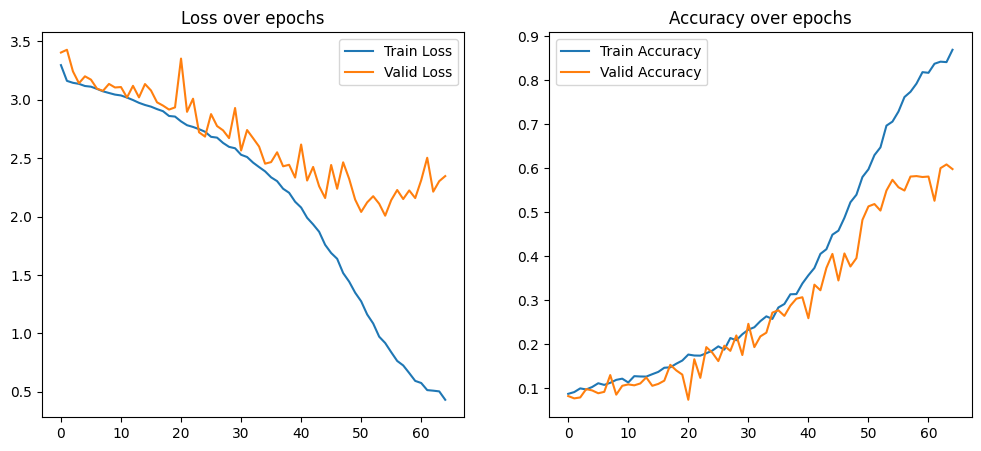

In [ ]:
# 학습 및 검증 과정 시각화
plt.figure(figsize=(12, 5))
# 손실 시각화
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")
plt.legend()
plt.title("Loss over epochs")

# 정확도 시각화
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(valid_accuracies, label="Valid Accuracy")
plt.legend()
plt.title("Accuracy over epochs")
# 그래프 출력
plt.show()

In [ ]:
# 모델의 가중치만 저장하는 코드
torch.save(model.state_dict(), '/content/drive/MyDrive/model_weights.pth')
print("Model weights saved successfully.")

Model weights saved successfully.
